# 2PLM with Stan

2 parameters logistic model (2PLM)

$$
P(u_{ij} = 1) = \frac{1}{1+ \exp(-a_j ( \theta_i - b_j))}
$$

- $\theta_i$: ability of respondent $i$
- $a_j$: discrimination parameter of item $j$
- $b_j$: difficulty parameter of item $j$

## Priors

$$
\theta_i \sim \mathcal{N}(0, 1), \quad
a_j \sim \text{LogNormal}(0, 0.5), \quad
b_j \sim \mathcal{N}(0, 1)
$$

Fixing $\theta \sim \mathcal{N}(0,1)$ resolves the location/scale non-identifiability of IRT models.

In [1]:
import nest_asyncio
nest_asyncio.apply()

import numpy as np
import matplotlib.pyplot as plt
import stan
import arviz as az

## Data Generation

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = rng.normal(0, 1, J)

# Generate responses
logit_p = a_true[None, :] * (theta_true[:, None] - b_true[None, :])
p = 1 / (1 + np.exp(-logit_p))
Y = rng.binomial(1, p).astype(int)

print(f"Response matrix shape: {Y.shape}")
print(f"Mean correct rate: {Y.mean():.3f}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b range: [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape: (100, 20)
Mean correct rate: 0.464
True a range: [0.42, 2.23]
True b range: [-1.47, 2.91]


## Stan Model

In [3]:
model_code = """
data {
  int<lower=1> N;
  int<lower=1> J;
  array[N, J] int<lower=0, upper=1> Y;
}
parameters {
  vector[N] theta;
  vector<lower=0>[J] a;
  vector[J] b;
}
model {
  theta ~ normal(0, 1);
  a ~ lognormal(0, 0.5);
  b ~ normal(0, 1);

  for (i in 1:N) {
    Y[i] ~ bernoulli_logit(a .* (theta[i] - b));
  }
}
"""

## Compile and Sample

Compilation takes ~30 seconds on first run.

In [4]:
%%time
data_dict = {"N": N, "J": J, "Y": Y.tolist()}

posterior = stan.build(model_code, data=data_dict, random_seed=42)
fit = posterior.sample(num_chains=4, num_samples=1000, num_warmup=1000, random_seed=0)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x74c1915e3f40> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x74c1915e3f40> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x74c1915e3f40> is already entered
Exception in callback Task.__step()
h

CPU times: user 390 ms, sys: 120 ms, total: 510 ms
Wall time: 526 ms


## Results

In [5]:
idata = az.from_pystan(fit)
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.14,0.33,0.56,1.78,0.01,0.01,3637.28,3151.05,1.0
a[1],2.25,0.74,1.05,3.60,0.01,0.02,2697.19,2719.69,1.0
a[2],0.66,0.21,0.30,1.05,0.00,0.00,4015.10,3387.30,1.0
a[3],1.58,0.48,0.77,2.49,0.01,0.01,3203.89,2718.06,1.0
a[4],0.74,0.23,0.34,1.15,0.00,0.00,3704.29,3170.22,1.0
a[5],0.83,0.25,0.36,1.28,0.00,0.00,3723.93,3509.67,1.0
a[6],0.90,0.26,0.46,1.42,0.00,0.00,3701.94,2958.31,1.0
a[7],1.29,0.36,0.65,1.93,0.01,0.01,3700.84,3016.66,1.0
a[8],1.16,0.34,0.54,1.74,0.01,0.01,3491.98,3220.01,1.0
a[9],0.75,0.24,0.35,1.21,0.00,0.00,4235.28,3347.82,1.0


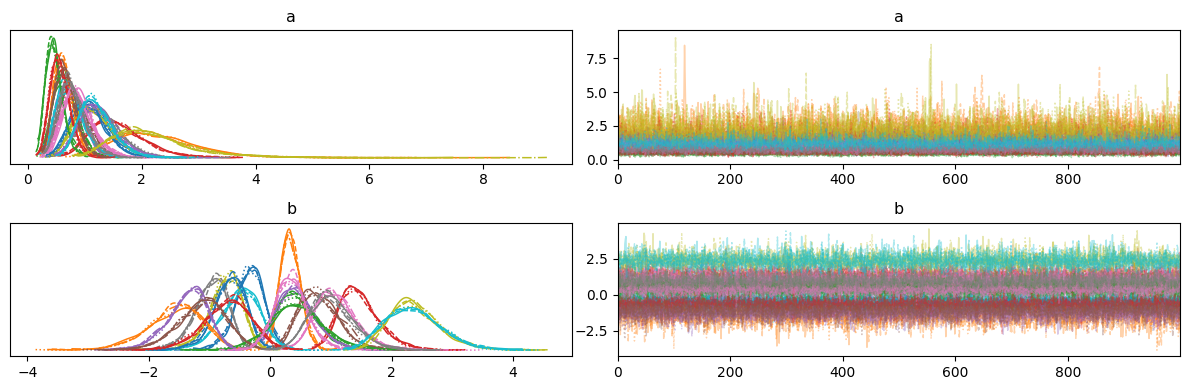

In [6]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

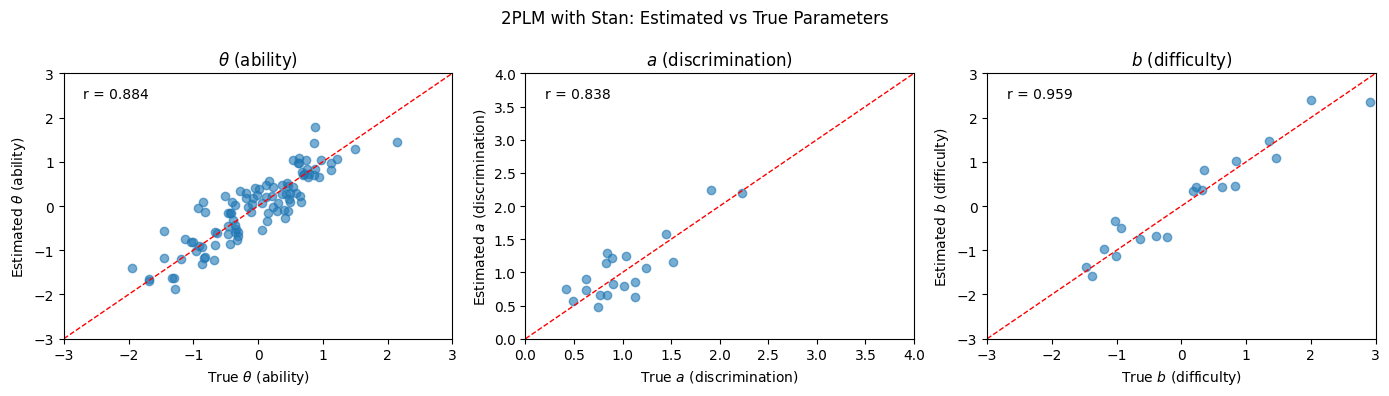

In [7]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, true_vals, est_vals, label, lim in zip(
    axes,
    [theta_true, a_true, b_true],
    [theta_est, a_est, b_est],
    [r"$\theta$ (ability)", r"$a$ (discrimination)", r"$b$ (difficulty)"],
    [(-3, 3), (0, 4), (-3, 3)],
):
    ax.scatter(true_vals, est_vals, alpha=0.6)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Estimated {label}")
    ax.set_title(label)
    corr = np.corrcoef(true_vals, est_vals)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, va="top")

plt.suptitle("2PLM with Stan: Estimated vs True Parameters")
plt.tight_layout()
plt.show()